<a href="https://colab.research.google.com/github/isnasabrinaiftinan/compfest-2026/blob/main/code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

train = pd.read_csv('/content/drive/MyDrive/COMPFEST/train.csv')
test = pd.read_csv('/content/drive/MyDrive/COMPFEST/test.csv')

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold
from sklearn.metrics import root_mean_squared_error
from lightgbm import LGBMRegressor

target_col = 'property_organic_content'
features = [c for c in train.columns if c not in ['sample_id', 'source_id', target_col]]

X = train[features]
y = train[target_col]
X_test = test[features]

cat_features = X.select_dtypes(include=['object', 'category']).columns.tolist()
for c in cat_features:
    X[c] = X[c].astype('category')
    X_test[c] = X_test[c].astype('category')

kf = KFold(n_splits=5, shuffle=True, random_state=42)
oof_preds = np.zeros(len(train))
test_preds = np.zeros(len(test))

print("Memulai proses pelatihan model...")

for fold, (train_idx, val_idx) in enumerate(kf.split(X, y)):
    X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
    X_val, y_val = X.iloc[val_idx], y.iloc[val_idx]

    # --- MASUKKAN KODE BARU DI SINI ---
    model = LGBMRegressor(
        n_estimators=1000,
        learning_rate=0.03,
        num_leaves=31,
        random_state=42,
        n_jobs=-1,
        min_child_samples=20
    )
    from lightgbm import early_stopping
    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        callbacks=[early_stopping(stopping_rounds=50, verbose=False)]
    )
    # ----------------------------------

    oof_preds[val_idx] = model.predict(X_val)

    test_preds += model.predict(X_test) / kf.n_splits
    print(f"-> Fold {fold+1} selesai dididik.")

rmse_score = root_mean_squared_error(y, oof_preds)
print(f"\nHasil Akhir - Lokal CV RMSE Score: {rmse_score:.4f}")

submission = pd.DataFrame({'sample_id': test['sample_id'], target_col: test_preds})
submission.to_csv('submission_baseline.csv', index=False)
print("Berkas 'submission_baseline.csv' berhasil dibuat!")


/tmp/ipykernel_1283/1145012505.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[c] = X[c].astype('category')
/tmp/ipykernel_1283/1145012505.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test[c] = X_test[c].astype('category')
/tmp/ipykernel_1283/1145012505.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/us

Memulai proses pelatihan model...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002296 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 9649
[LightGBM] [Info] Number of data points in the train set: 8968, number of used features: 47
[LightGBM] [Info] Start training from score 34.181334
-> Fold 1 selesai dididik.
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.006056 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 9645
[LightGBM] [Info] Number of data points in the train set: 8968, number of used features: 47
[LightGBM] [Info] Start training from score 34.200474
-> Fold 2 selesai dididik.
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.114007 seconds.
You can set `force_row_wise=true` to remove the overhead.
An

In [ ]:
import pandas as pd
import numpy as np

print("=== JAWABAN SOAL 5A (Rata-rata Kandungan Organik per Ekosistem) ===")
p25_acidity = train['property_acidity_index'].quantile(0.25)
mean_cec = train['cation_exchange_capacity'].mean()

filtered_5a = train[
    (train['property_acidity_index'] < p25_acidity) &
    (train['cation_exchange_capacity'] < mean_cec)
]

print(filtered_5a.groupby('biome')['property_organic_content'].mean().to_string())


print("\n\n=== JAWABAN SOAL 5B (Deteksi Jumlah Outlier per Kelompok) ===")
def count_outliers(group):
    q1 = group.quantile(0.25)
    q3 = group.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    return ((group < lower_bound) | (group > upper_bound)).sum()

outlier_counts = train.groupby(['land_cover_type', 'geo_zone_macro'])['property_organic_content'].apply(count_outliers).reset_index()
outlier_counts.columns = ['Land Cover', 'Geo Zone Macro', 'Jumlah Outlier']

print(outlier_counts[outlier_counts['Jumlah Outlier'] > 0].to_string(index=False))


print("\n\n=== JAWABAN SOAL 6 (Matriks Korelasi Variabel Fisik & Kimia Tanah) ===")
kation_cols = ['cation_Ca', 'cation_Mg', 'cation_Na', 'cation_exchange_capacity', 'property_particle_coarse', 'property_particle_fine']
correlation_matrix = train[kation_cols].corr()

print(correlation_matrix.round(2))


=== JAWABAN SOAL 5A (Rata-rata Kandungan Organik per Ekosistem) ===
biome
Amazonia          27.612371
Caatinga          19.982671
Cerrado           24.270450
Mata Atlantica    21.317980
Unknown           43.686810


=== JAWABAN SOAL 5B (Deteksi Jumlah Outlier per Kelompok) ===
                   Land Cover Geo Zone Macro  Jumlah Outlier
            Amazon Rainforest             NE               4
  Areas of Ecological Tension             MW              31
  Areas of Ecological Tension              N               2
  Areas of Ecological Tension             NE               1
  Areas of Ecological Tension             SE               4
    Dense Ombrophylous Forest              N               4
    Dense Ombrophylous Forest             NE               1
    Dense Ombrophylous Forest             SE               5
     Open Ombrophylous Forest              N               1
                     Savannah             MW               5
                     Savannah              N       

/tmp/ipykernel_1283/2160750613.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_5a, x='property_organic_content', y='biome', palette='viridis')


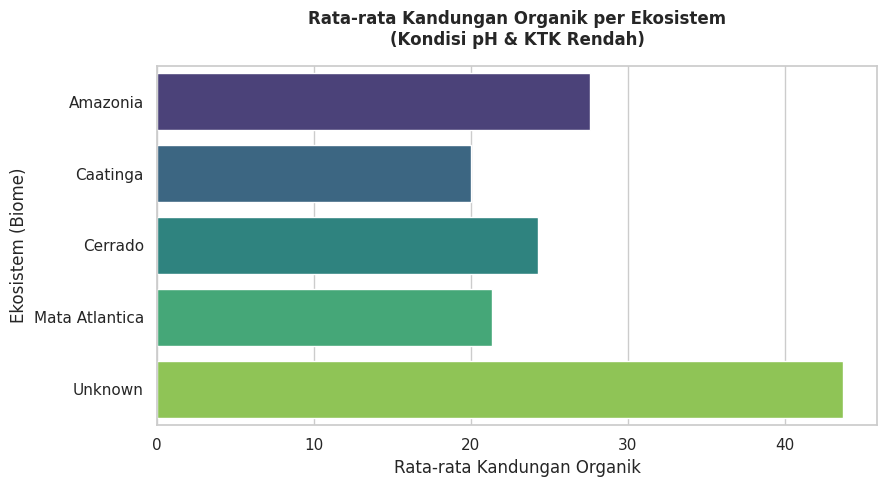

/tmp/ipykernel_1283/2160750613.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_outliers, x='Jumlah Outlier', y='Kelompok', palette='magma')


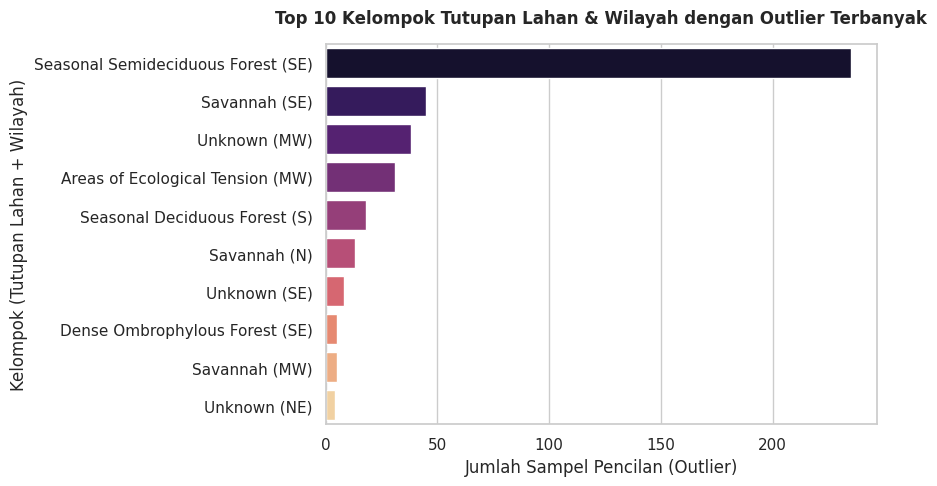

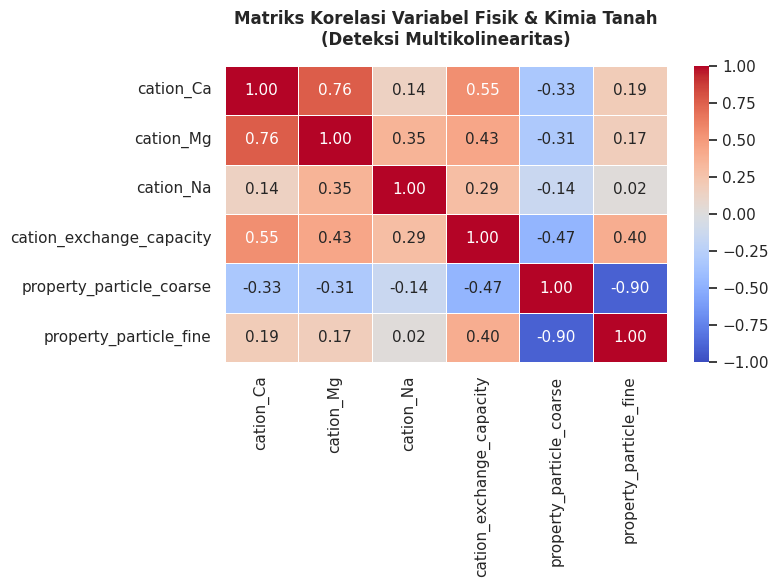

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 11})

# ==========================================
# 1. GRAFIK UNTUK SOAL 5A
# ==========================================
p25_acidity = train['property_acidity_index'].quantile(0.25)
mean_cec = train['cation_exchange_capacity'].mean()
filtered_5a = train[(train['property_acidity_index'] < p25_acidity) & (train['cation_exchange_capacity'] < mean_cec)]
df_5a = filtered_5a.groupby('biome')['property_organic_content'].mean().reset_index()

plt.figure(figsize=(9, 5))
sns.barplot(data=df_5a, x='property_organic_content', y='biome', palette='viridis')
plt.title('Rata-rata Kandungan Organik per Ekosistem\n(Kondisi pH & KTK Rendah)', fontweight='bold', pad=15)
plt.xlabel('Rata-rata Kandungan Organik')
plt.ylabel('Ekosistem (Biome)')
plt.tight_layout()
plt.savefig('grafik_soal_5a.png', dpi=300)
plt.show()

# ==========================================
# 2. GRAFIK UNTUK SOAL 5B (Top 10 Kelompok Outlier Terbanyak)
# ==========================================
def count_outliers(group):
    q1 = group.quantile(0.25)
    q3 = group.quantile(0.75)
    iqr = q3 - q1
    return ((group < (q1 - 1.5 * iqr)) | (group > (q3 + 1.5 * iqr))).sum()

outlier_counts = train.groupby(['land_cover_type', 'geo_zone_macro'])['property_organic_content'].apply(count_outliers).reset_index()
outlier_counts.columns = ['Land Cover', 'Geo Zone Macro', 'Jumlah Outlier']
top_outliers = outlier_counts[outlier_counts['Jumlah Outlier'] > 0].sort_values(by='Jumlah Outlier', ascending=False).head(10)
top_outliers['Kelompok'] = top_outliers['Land Cover'] + ' (' + top_outliers['Geo Zone Macro'] + ')'

plt.figure(figsize=(9, 5))
sns.barplot(data=top_outliers, x='Jumlah Outlier', y='Kelompok', palette='magma')
plt.title('Top 10 Kelompok Tutupan Lahan & Wilayah dengan Outlier Terbanyak', fontweight='bold', pad=15)
plt.xlabel('Jumlah Sampel Pencilan (Outlier)')
plt.ylabel('Kelompok (Tutupan Lahan + Wilayah)')
plt.tight_layout()
plt.savefig('grafik_soal_5b.png', dpi=300)
plt.show()

# ==========================================
# 3. GRAFIK UNTUK SOAL 6 (Heatmap Korelasi)
# ==========================================
kation_cols = ['cation_Ca', 'cation_Mg', 'cation_Na', 'cation_exchange_capacity', 'property_particle_coarse', 'property_particle_fine']
correlation_matrix = train[kation_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title('Matriks Korelasi Variabel Fisik & Kimia Tanah\n(Deteksi Multikolinearitas)', fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('grafik_soal_6.png', dpi=300)
plt.show()


In [ ]:
import pandas as pd

p25_acidity = train['property_acidity_index'].quantile(0.25)
mean_cec = train['cation_exchange_capacity'].mean()

filtered_df = train[
    (train['property_acidity_index'] < p25_acidity) &
    (train['cation_exchange_capacity'] < mean_cec)
]

result = filtered_df.groupby('biome')['property_organic_content'].mean()
print("=== HASIL NOMOR 5A ===")
print(result)


=== HASIL NOMOR 5A ===
biome
Amazonia          27.612371
Caatinga          19.982671
Cerrado           24.270450
Mata Atlantica    21.317980
Unknown           43.686810
Name: property_organic_content, dtype: float64
